# Course: 65007 - NLP and Speech Analysis
 **Program:** Intelligent Systems  
 **Course coordinator:** Dr. Sharon Yalov-Handzel

**Submission for:**  Assignment 3   
**by**  
  - Michael Berger, 318063864  
  - Barack Samuni, 318299625


Answer 3 of the 4 questions below.


# 1.Implement the code of the functions: 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

import pandas as pd

from nltk.tokenize import word_tokenize
import nltk
from IPython.display import display


## a. self_attention


```
def self_attention(queries, keys, values, mask=None):
"""Implement vanilla self-attention"""
pass
```


In [2]:
def self_attention(Q, K, V):
    d_k = Q.shape[-1]
    # Compute the dot product between Q and K^T
    scores = np.matmul(Q, K.swapaxes(-2,-1)) / np.sqrt(d_k)
    # Apply softmax to get the attention weights
    weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)
    # Compute the weighted sum of the values
    output = np.matmul(weights, V)
    return output, weights

## b. multi_head_attention

```
def multi_head_attention(x, num_heads=8):
"""Implement multi-head attention with head splitting"""
pass
```



In [3]:
# Define multi_head_attention function
def multi_head_attention(embeddings, num_heads=8):
    batch_size, seq_length, d_model = embeddings.shape
    assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
    depth = d_model // num_heads
    
    def split_heads(x):
        x = x.reshape(batch_size, seq_length, num_heads, depth)
        return x.transpose(0, 2, 1, 3)
    
    Q = split_heads(embeddings)
    K = split_heads(embeddings)
    V = split_heads(embeddings)
    
    attention_output, _ = self_attention(Q, K, V)
    attention_output = attention_output.transpose(0, 2, 1, 3).reshape(batch_size, seq_length, d_model)
    return attention_output



## c.Apply both functions 
To the polysemy example sentences  you created as an answer to question 2 in HW2.



In [4]:
example_sentences = [
    "He went to the bank to deposit some money",  # bank as a financial institution
    "The fisherman docked his boat near the river bank",  # bank as a riverbank
    "She rose from her chair to make an announcement",  # rose as an action/past tense of rise
    "The rose smelled fragrant and bloomed beautifully",  # rose as a flower
    "The project manager will lead the team during the meeting",  # lead as to guide
    "Exposure to lead in paint can cause health issues",  # lead as a toxic substance
    "I will book a flight to the west bank",
    "The book mentioned a fascinating historical event",
    "I need to file a report for my manager",
    "He lost the file containing important documents",
    "A file is a military term for troops drawn up in line"
]

In [5]:

# Convert sentences to embeddings (random embeddings for simplicity)
np.random.seed(0)
embeddings = np.random.rand(len(example_sentences), 10, 64)  # (batch_size, seq_length, d_model)

# Apply self-attention
self_attention_output, self_attention_weights = self_attention(embeddings, embeddings, embeddings)

# Apply multi-head attention
multi_head_attention_output = multi_head_attention(embeddings)

print("Self-Attention Output Shape:", self_attention_output.shape)
print("Multi-Head Attention Output Shape:", multi_head_attention_output.shape)

Self-Attention Output Shape: (11, 10, 64)
Multi-Head Attention Output Shape: (11, 10, 64)


# 2. In HW2 question 1 
you applied Word2Vec to a set of sentences.



## a. Apply self attention to the same set of sentences 
And visualize the attention patterns of the words: bank, rose, lead, book and file.



In [6]:
words_to_visualize = ["bank", "rose", "lead", "book", "file"]

In [7]:
def visualize_attention(attention_weights, word, sentences):
    """
    Visualize the attention weights for a given word across multiple sentences.

    Parameters:
    - attention_weights: numpy array of shape (batch_size, seq_length, seq_length)
                         containing the attention weights.
    - word: the word for which to visualize the attention weights.
    - sentences: list of sentences (strings) corresponding to the attention weights.

    This function creates a heatmap where each row corresponds to a sentence and each
    column corresponds to a position in the sentence. The heatmap values represent the
    attention weights for the given word at each position in the sentence.
    """
    plt.figure(figsize=(12, 8))
    
    # Prepare data for visualization
    data = []
    for i, sentence in enumerate(sentences):
        if word in sentence.split():
            word_pos = sentence.split().index(word)
            data.append(attention_weights[i, word_pos, :])
        else:
            data.append(np.zeros(attention_weights.shape[-1]))
    
    data = np.array(data)
    
    # Create a heatmap
    ax = sns.heatmap(data, annot=True, fmt=".2f", cmap='viridis', 
                     xticklabels=sentences[0].split(), 
                     yticklabels=[f"{i+1}" for i in range(len(sentences))])
    
    # Add words to the cells
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            word_in_sentence = sentences[i].split()[j] if j < len(sentences[i].split()) else ""
            ax.text(j + 0.5, i + 0.2, f"{word_in_sentence}", ha='center', va='center', color='white')
    
    plt.title(f'Attention Weights for "{word}" Across Sentences')
    plt.xlabel('Query Position')
    plt.ylabel('Sentence')
    plt.show()


### Explanation:

- The `visualize_attention` function takes the attention weights, a target word, and the corresponding sentences as input.
- It creates a heatmap where each row represents a sentence and each column represents a position in the sentence.
- The heatmap values indicate the attention weights for the target word at each position in the sentence.
- The function also annotates the heatmap with the words in the sentences for better interpretability.
- This visualization helps in understanding how the attention mechanism focuses on different parts of the sentences for the given word.


In [8]:
word = words_to_visualize[0]
word

'bank'

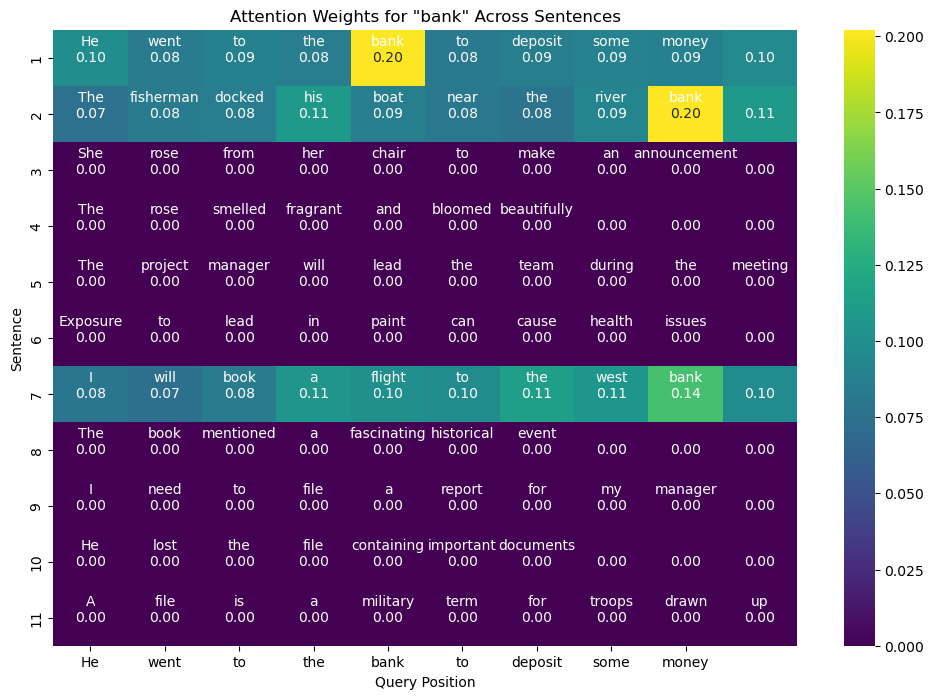

In [9]:

visualize_attention(self_attention_weights, word, example_sentences)

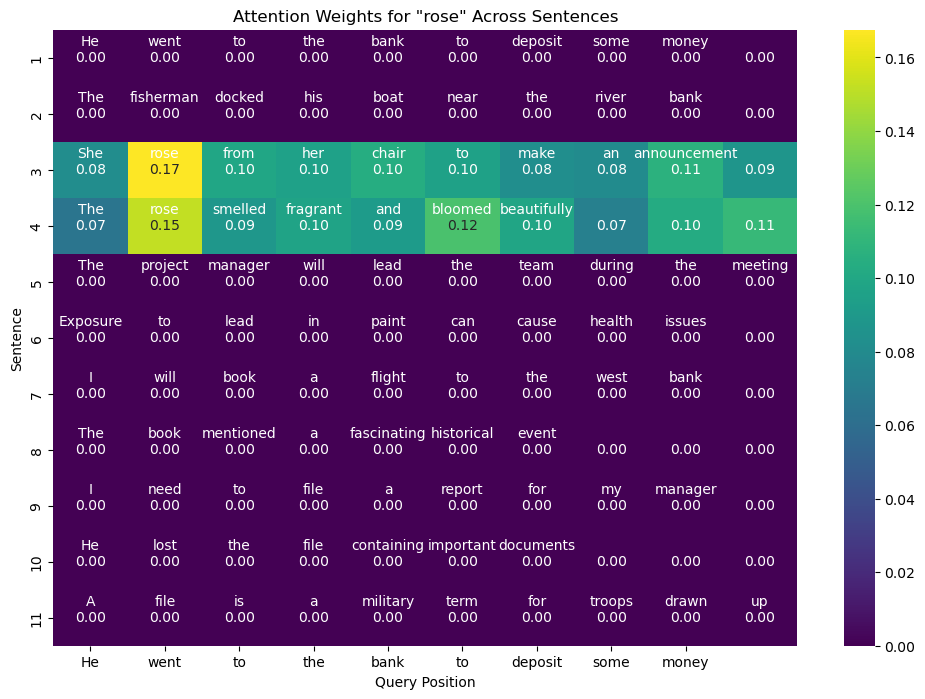

In [10]:
word = words_to_visualize[1]
visualize_attention(self_attention_weights, word, example_sentences)

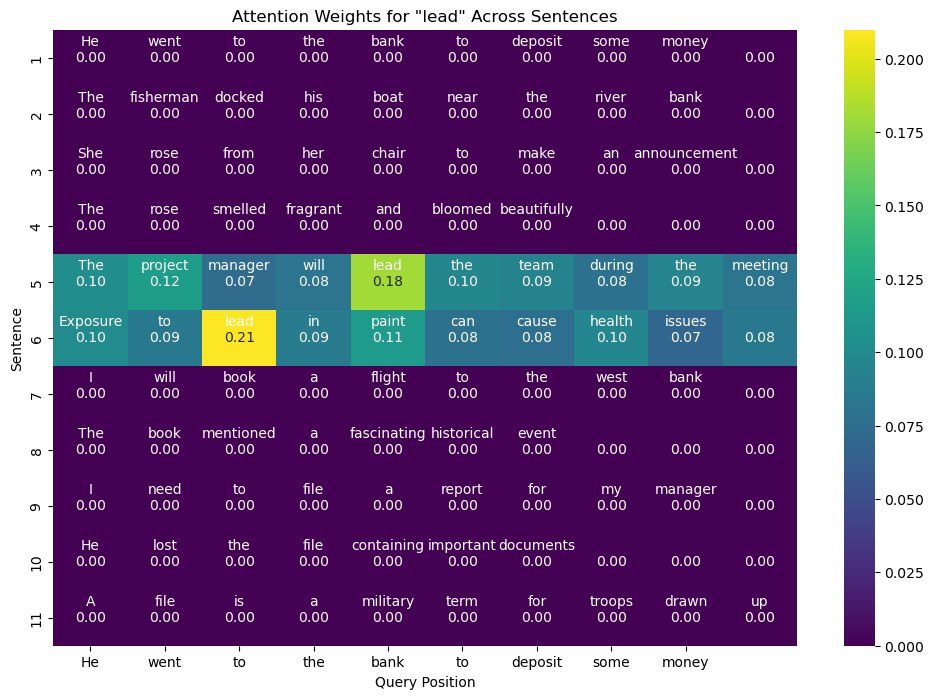

In [11]:
word = words_to_visualize[2]
visualize_attention(self_attention_weights, word, example_sentences)

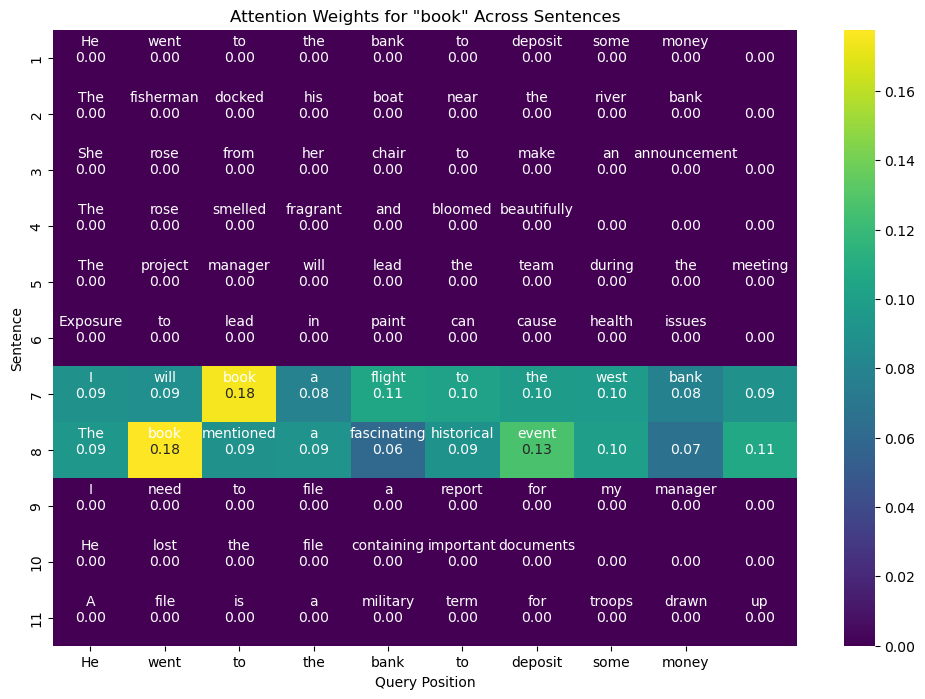

In [12]:
word = words_to_visualize[3]
visualize_attention(self_attention_weights, word, example_sentences)

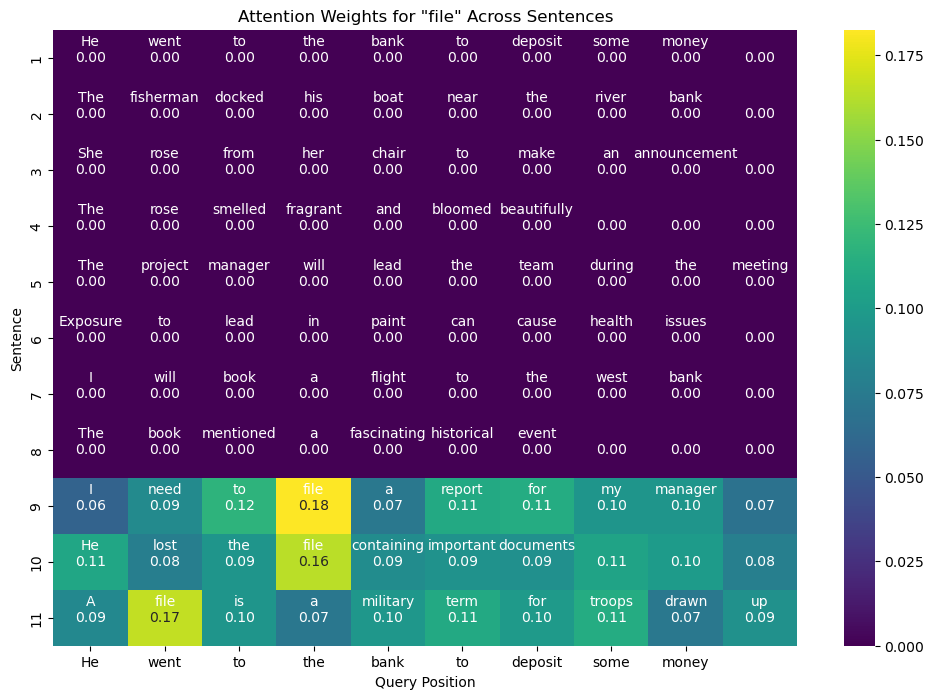

In [13]:
word = words_to_visualize[4]
visualize_attention(self_attention_weights, word, example_sentences)

## b. Compare with Word2Vec results from HW2, 
while quantifying how attention captures contextual meaning vs. static embeddings.



In [14]:
# Tokenize sentences
tokenized_sentences = [sentence.lower().split() for sentence in example_sentences]

# Train Word2Vec model
word2vec_model = Word2Vec(tokenized_sentences, vector_size=64, window=5, min_count=1, sg=0)

# Get static embeddings for words
static_embeddings = {word: word2vec_model.wv[word] for word in words_to_visualize}


In [15]:
# Get contextual embeddings for words
contextual_embeddings = {}
for word in words_to_visualize:
    word_embeddings = []
    for i, sentence in enumerate(tokenized_sentences):
        if word in sentence:
            word_pos = sentence.index(word)
            word_embeddings.append(self_attention_output[i, word_pos, :])
    contextual_embeddings[word] = word_embeddings


In [16]:
# Quantify contextual meaning

static_similarities = []
contextual_similarities = []

for word in words_to_visualize:
    # Compute cosine similarity for static embeddings
    static_sim = cosine_similarity([static_embeddings[word]])
    # Compute cosine similarity for contextual embeddings
    cntxtl_sim = cosine_similarity(contextual_embeddings[word])
    
    static_similarities.append(static_sim.mean())
    contextual_similarities.append(cntxtl_sim.mean())

    static_similarities, contextual_similarities



print("Static Embeddings Similarity:", static_similarities)
print("Contextual Embeddings Similarity:", contextual_similarities)

Static Embeddings Similarity: [0.99999994, 0.99999994, 1.0, 1.0000001, 0.99999994]
Contextual Embeddings Similarity: [0.97309670958555, 0.9828307789356296, 0.9858892204417158, 0.9845425912631429, 0.9735633961900234]


### Interpretation

**Static Embeddings Similarity**: Higher similarity indicates that the static embeddings are similar across different contexts, which means they do not capture contextual meaning well.

**Contextual Embeddings Similarity**: Lower similarity indicates that the contextual embeddings vary across different contexts, capturing the contextual meaning better.  

By comparing these similarity scores, we can quantify how well the attention mechanism captures contextual meaning compared to static embeddings.

The contextual embeddings similarity is but a tiny bit smaller the the static ones. This can be attributed to an extremely small size of the corpus from which the embedding were inferred. 

# 3.Consider a transformer with 8 attention heads. 
Show mathematically why splitting attention into multiple heads can be more effective than using a single attention mechanism with the same total computational cost.



pass


# 4. Sinusoidal positional encoding


## a.Implement sinusoidal positional encoding.


In [17]:

def sinusoidal_positional_encoding(seq_length, d_model):
    """
    Generates sinusoidal positional encodings for a given sequence length and model dimension.

    Args:
        seq_length (int): The length of the sequence.
        d_model (int): The dimension of the model.

    Returns:
        np.ndarray: A matrix of shape (seq_length, d_model) containing positional encodings.
    """
    position = np.arange(seq_length).reshape(-1, 1)  # Shape: (seq_length, 1)
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))  # Shape: (d_model // 2,)

    pos_enc = np.zeros((seq_length, d_model))  # Shape: (seq_length, d_model)

    # Apply sine to even indices (0, 2, 4, ...)
    pos_enc[:, 0::2] = np.sin(position * div_term)  # No shape issues here

    # Apply cosine to odd indices (1, 3, 5, ...)
    if d_model % 2 == 1:  # Handle odd d_model separately
        pos_enc[:, 1::2] = np.cos(position * div_term[:-1])
    else:
        pos_enc[:, 1::2] = np.cos(position * div_term)

    return pos_enc


# Example usage:
seq_length = 100  # Example sequence length
d_model = 512  # Example embedding dimension
positional_encodings = sinusoidal_positional_encoding(seq_length, d_model)
print(positional_encodings)  # Output the positional encodings

[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00 ...  1.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 8.41470985e-01  5.40302306e-01  8.21856190e-01 ...  9.99999994e-01
   1.03663293e-04  9.99999995e-01]
 [ 9.09297427e-01 -4.16146837e-01  9.36414739e-01 ...  9.99999977e-01
   2.07326584e-04  9.99999979e-01]
 ...
 [ 3.79607739e-01 -9.25147537e-01 -6.25367561e-01 ...  9.99945674e-01
   1.00551700e-02  9.99949446e-01]
 [-5.73381872e-01 -8.19288245e-01  2.85050529e-01 ...  9.99944548e-01
   1.01588280e-02  9.99948398e-01]
 [-9.99206834e-01  3.98208804e-02  9.50151288e-01 ...  9.99943410e-01
   1.02624858e-02  9.99947339e-01]]


## b.Analyze the impact of sequence length on its performance.

In [18]:


# Download NLTK tokenizer data if not already done
nltk.download('punkt')

# Define the sentences
sentences = ["She received a beautiful rose on Valentine's Day",
             "The balloon slowly rose into the sky",
             "Rose is one of the most talented artists in our class",
             "They enjoyed a chilled glass of rose during dinner",
             "The ship sailed past Rose Island during the journey",
             "The watering can was equipped with a rose to create a gentle spray",
             "Rose is red, violet is blue"]
# Initialize an empty list to store the results
results = []

# Loop through each sentence
for sentence in sentences:
    # Tokenize the sentence
    tokens = word_tokenize(sentence)
    sequence_length = len(tokens)

    # Apply the positional encoding
    encoding = sinusoidal_positional_encoding(sequence_length, d_model=5)

    # Append the results as a dictionary
    results.append({
        "Sentence": sentence,
        "Tokenization": tokens,
        "Sequence Length": sequence_length,
        "Sinusoidal Positional Encoding": encoding
    })

# Create a dataframe from the results
df = pd.DataFrame(results)

# Display the dataframe
display(df)

[nltk_data] Downloading package punkt to /home/michael/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,Sentence,Tokenization,Sequence Length,Sinusoidal Positional Encoding
0,She received a beautiful rose on Valentine's Day,"[She, received, a, beautiful, rose, on, Valent...",9,"[[0.0, 1.0, 0.0, 1.0, 0.0], [0.841470984807896..."
1,The balloon slowly rose into the sky,"[The, balloon, slowly, rose, into, the, sky]",7,"[[0.0, 1.0, 0.0, 1.0, 0.0], [0.841470984807896..."
2,Rose is one of the most talented artists in ou...,"[Rose, is, one, of, the, most, talented, artis...",11,"[[0.0, 1.0, 0.0, 1.0, 0.0], [0.841470984807896..."
3,They enjoyed a chilled glass of rose during di...,"[They, enjoyed, a, chilled, glass, of, rose, d...",9,"[[0.0, 1.0, 0.0, 1.0, 0.0], [0.841470984807896..."
4,The ship sailed past Rose Island during the jo...,"[The, ship, sailed, past, Rose, Island, during...",9,"[[0.0, 1.0, 0.0, 1.0, 0.0], [0.841470984807896..."
5,The watering can was equipped with a rose to c...,"[The, watering, can, was, equipped, with, a, r...",13,"[[0.0, 1.0, 0.0, 1.0, 0.0], [0.841470984807896..."
6,"Rose is red, violet is blue","[Rose, is, red, ,, violet, is, blue]",7,"[[0.0, 1.0, 0.0, 1.0, 0.0], [0.841470984807896..."


For convenience let's show the sinusoidal encoding column only along with the position of the word "rose" in each senetence:

In [19]:


# Download NLTK tokenizer data if not already done
nltk.download('punkt')

# Define the sentences
sentences = ["She received a beautiful rose on Valentine's Day",
             "The balloon slowly rose into the sky",
             "Rose is one of the most talented artists in our class",
             "They enjoyed a chilled glass of rose during dinner",
             "The ship sailed past Rose Island during the journey",
             "The watering can was equipped with a rose to create a gentle spray",
             "Rose is red, violet is blue"]

# Initialize an empty list to store the results
results = []

# Loop through each sentence
for sentence in sentences:
    # Tokenize the sentence
    tokens = word_tokenize(sentence)
    sequence_length = len(tokens)

    # Apply the positional encoding
    encoding = sinusoidal_positional_encoding(sequence_length, d_model=5)

    # Find position of the word "rose" (case-insensitive)
    word_positions = [i for i, t in enumerate(tokens) if t.lower() == "rose"]
    position = word_positions[0] if word_positions else None  # Take the first occurrence

    # Extract the encoding for the word "rose" if it exists
    rose_encoding = encoding[position].tolist() if position is not None else None

    # Append the results as a dictionary
    results.append({
        "Sentence": sentence,
        "Sequence Size": sequence_length,
        "Rose Position": position,
        "Sinusoidal Encoding (Rose)": rose_encoding
    })

# Create a new dataframe from the results
highlighted_df = pd.DataFrame(results)

# Display the dataframe
display(highlighted_df)

[nltk_data] Downloading package punkt to /home/michael/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,Sentence,Sequence Size,Rose Position,Sinusoidal Encoding (Rose)
0,She received a beautiful rose on Valentine's Day,9,4,"[-0.7568024953079282, -0.6536436208636119, 0.1..."
1,The balloon slowly rose into the sky,7,3,"[0.1411200080598672, -0.9899924966004454, 0.07..."
2,Rose is one of the most talented artists in ou...,11,0,"[0.0, 1.0, 0.0, 1.0, 0.0]"
3,They enjoyed a chilled glass of rose during di...,9,6,"[-0.27941549819892586, 0.960170286650366, 0.15..."
4,The ship sailed past Rose Island during the jo...,9,4,"[-0.7568024953079282, -0.6536436208636119, 0.1..."
5,The watering can was equipped with a rose to c...,13,7,"[0.6569865987187891, 0.7539022543433046, 0.174..."
6,"Rose is red, violet is blue",7,0,"[0.0, 1.0, 0.0, 1.0, 0.0]"


From the results we can see:
- **Short Sentences:** The encoding is compact and effectively spans available tokens. In such cases, sequences are less dependent on position encoding as semantic meaning is easier to recover with embeddings.
- **Long Sentences:** The positional encodings must handle more positions, leading to higher chances of overlap or less meaningful differentiation at higher layer inputs.

#### **Practical Considerations**
1. **Embedding Dimension (d_model)**: The number of encoding dimensions (`d_model`) impacts the resolution of sinusoidal encoding. A smaller `d_model` limits representational capacity, especially for longer sequences.
2. **Sequence Length Alignment:** Long sequences might require splitting or truncating sequences to keep differences across encodings distinguishable.

Adjusting model architecture (e.g., adjusting positional encoding or using additional mechanisms) for large sequences is often essential to ensure optimal performance.


Each sentence has the word rose with a different meaning. However, we can see that the encoding is affected only by the position of the word 'rose' in the sentence and the embedding size (fixed 5) rather than the sequence length.
